## Agglomerative clustering with scipy

In [1]:
import warnings

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from sklearn.datasets import make_blobs

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, inconsistent
from scipy.cluster import hierarchy

warnings.simplefilter(action='ignore', category=FutureWarning)

sns.set_theme()
plt.rcParams['figure.figsize'] = [9, 5]

In [3]:
# Set up the collors for hierarchical clustering
#tab10_colors = plt.cm.tab10.colors  
#tab10_as_hex = [mcolors.to_hex(color) for color in tab10_colors]
#hierarchy.set_link_color_palette(tab10_as_hex)

### Artificial dataset

In [4]:
# Create artificial dataset
X, labels = make_blobs(
    n_samples=120, centers=4, cluster_std=0.5, random_state=45
)

data_df = pd.DataFrame(X, columns=['dim1', 'dim2'])

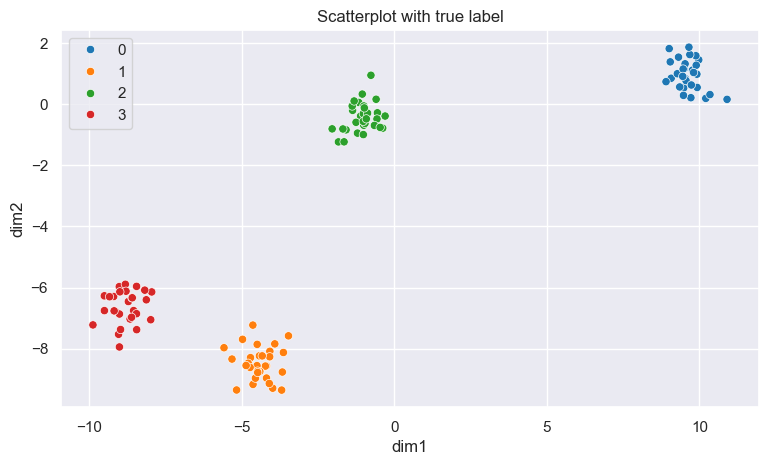

In [5]:
# Plot and colour based on reference label
sns.scatterplot(data_df, x='dim1', y='dim2', hue=labels, palette='tab10')
_ = plt.title('Scatterplot with true label')
plt.gca().set_aspect('equal', adjustable='box')

### "Height cut" based clustering

In [6]:
linkage_matrix = linkage(data_df, method='average')

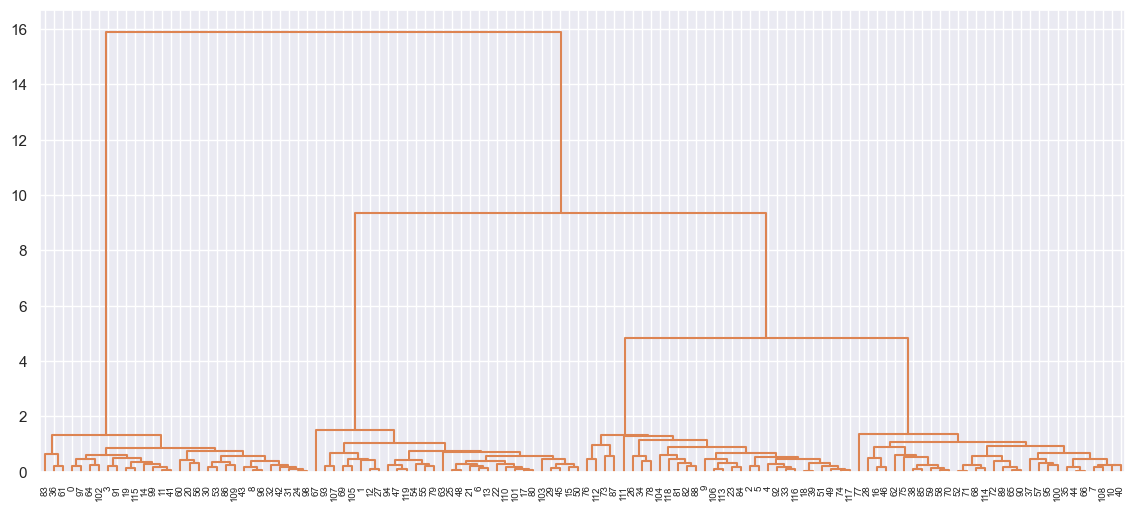

In [7]:
# Draw the dendrogram
plt.figure(figsize=(14,6))
_ = dendrogram(
    linkage_matrix, 
    leaf_font_size=7, 
    labels=data_df.index,
    above_threshold_color='black',
    color_threshold=20
)

In [8]:
cut_height = 4
clusters = fcluster(linkage_matrix, criterion='distance', t=cut_height)

In [9]:
clusters

array([1, 2, 3, 1, 3, 3, 2, 4, 1, 3, 4, 1, 2, 2, 1, 2, 4, 2, 3, 1, 1, 2,
       2, 3, 1, 2, 3, 2, 4, 2, 1, 1, 1, 3, 3, 4, 1, 4, 4, 3, 4, 1, 1, 1,
       4, 2, 4, 2, 2, 3, 2, 3, 4, 1, 2, 2, 1, 4, 4, 4, 1, 1, 4, 2, 1, 4,
       4, 2, 4, 2, 4, 4, 4, 3, 3, 4, 3, 4, 3, 2, 2, 3, 3, 1, 3, 4, 1, 3,
       3, 4, 4, 1, 3, 2, 2, 4, 1, 1, 1, 1, 4, 2, 1, 2, 3, 2, 3, 2, 4, 1,
       2, 3, 3, 3, 4, 1, 3, 3, 3, 2], dtype=int32)

Text(0.5, 1.0, 'Cut height = 4')

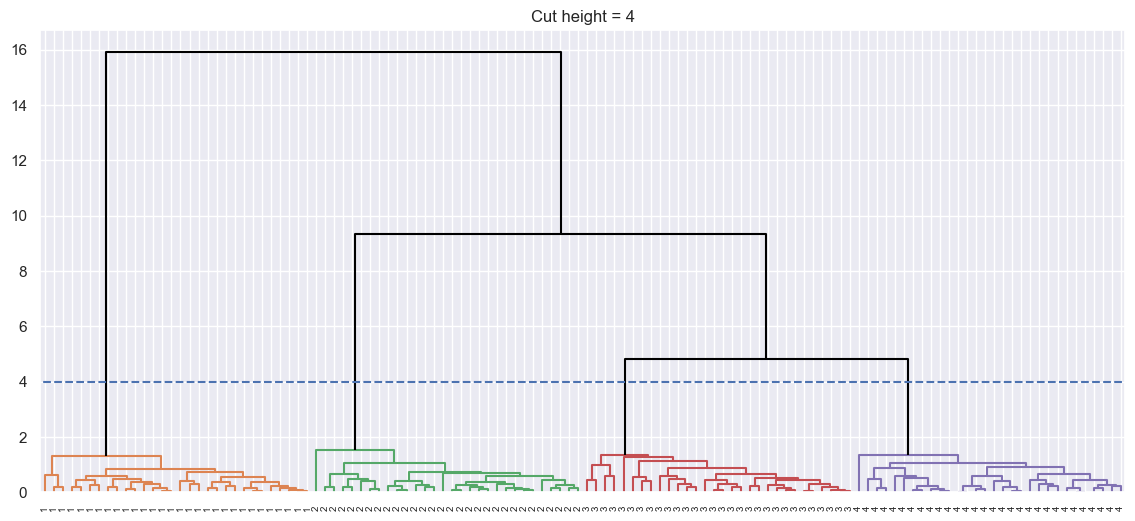

In [10]:
# Draw the dendrogram
plt.figure(figsize=(14,6))
_ = dendrogram(
    linkage_matrix, 
    leaf_font_size=7, 
    labels=clusters, 
    above_threshold_color='black', 
    color_threshold=cut_height
)
plt.hlines(cut_height, xmin=-100, xmax=10000, linestyles='--')
plt.title('Cut height = 4')

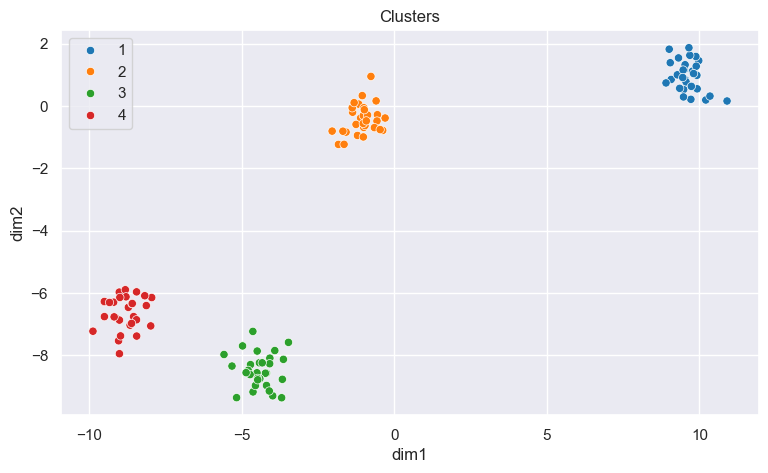

In [11]:
# Plot and colour based on reference label
sns.scatterplot(data_df, x='dim1', y='dim2', hue=clusters, palette='tab10')
_ = plt.title('Clusters')

### Number of clusters based clustering

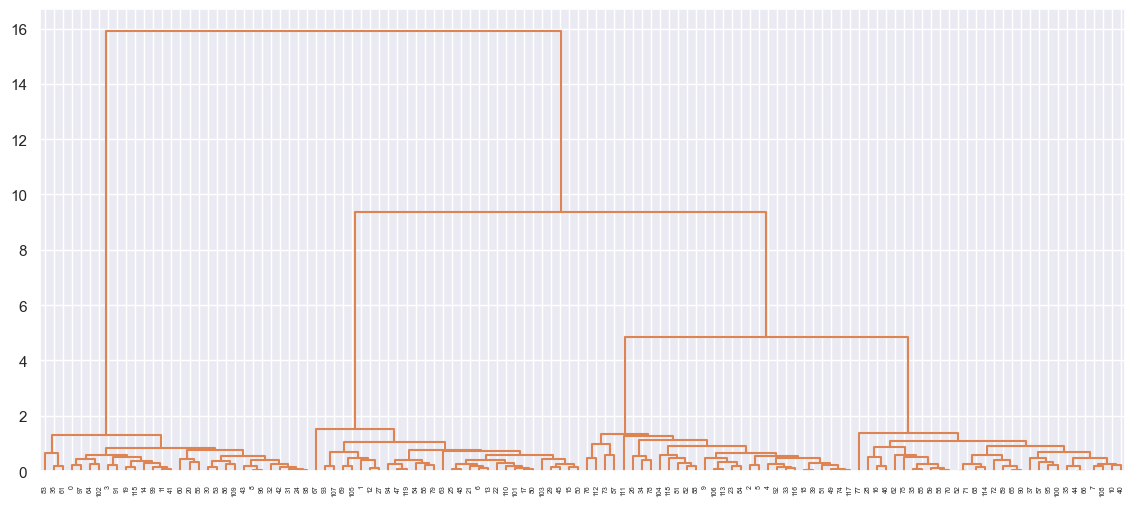

In [12]:
plt.figure(figsize=(14,6))
_ = dendrogram(linkage_matrix, color_threshold=20)

In [13]:
# Cluster based on wanted number of clusters
clusters = fcluster(Z=linkage_matrix, t=4, criterion='maxclust')
clusters

array([1, 2, 3, 1, 3, 3, 2, 4, 1, 3, 4, 1, 2, 2, 1, 2, 4, 2, 3, 1, 1, 2,
       2, 3, 1, 2, 3, 2, 4, 2, 1, 1, 1, 3, 3, 4, 1, 4, 4, 3, 4, 1, 1, 1,
       4, 2, 4, 2, 2, 3, 2, 3, 4, 1, 2, 2, 1, 4, 4, 4, 1, 1, 4, 2, 1, 4,
       4, 2, 4, 2, 4, 4, 4, 3, 3, 4, 3, 4, 3, 2, 2, 3, 3, 1, 3, 4, 1, 3,
       3, 4, 4, 1, 3, 2, 2, 4, 1, 1, 1, 1, 4, 2, 1, 2, 3, 2, 3, 2, 4, 1,
       2, 3, 3, 3, 4, 1, 3, 3, 3, 2], dtype=int32)

Text(0.5, 1.0, 'Clusters')

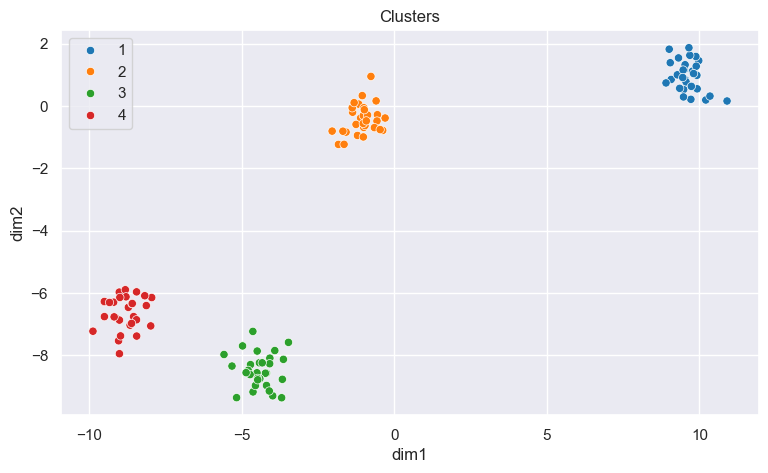

In [14]:
# Plot and colour based on reference label
sns.scatterplot(data_df, x='dim1', y='dim2', hue=clusters, palette='tab10')
plt.title('Clusters')